# Task 2: Exploratory Data Analysis (EDA)

## Objective
The objective of this task is to explore the dataset, understand its structure,
identify patterns and trends, detect anomalies, test hypotheses, and identify
potential data quality issues.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [5]:
df=pd.read_csv("student_data.csv")

In [6]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [7]:
print("Number of rows:",df.shape [0])
print("Number of columns:",df.shape [1])

Number of rows: 395
Number of columns: 33


## 1. Meaningful Questions

Before analyzing the dataset, the following questions are considered:

1. What are the main variables present in the dataset?
2. What are the data types of the variables?
3. Are there any missing values?
4. Are there duplicate records?
5. What are the distributions of numerical variables?
6. Are there any outliers?
7. What patterns or trends can be observed?
8. Are some variables correlated with each other?
9. Do different groups/categories show different behavior?
10. Can statistical testing support any observed relationship?
11. Are there any data quality issues that should be addressed?

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [10]:
print("columns names")
df.columns.tolist()

columns names


['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [11]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [12]:
for column in df.columns:
    print(column, ":", df[column].nunique(), "unique values")

school : 2 unique values
sex : 2 unique values
age : 8 unique values
address : 2 unique values
famsize : 2 unique values
Pstatus : 2 unique values
Medu : 5 unique values
Fedu : 5 unique values
Mjob : 5 unique values
Fjob : 5 unique values
reason : 4 unique values
guardian : 3 unique values
traveltime : 4 unique values
studytime : 4 unique values
failures : 4 unique values
schoolsup : 2 unique values
famsup : 2 unique values
paid : 2 unique values
activities : 2 unique values
nursery : 2 unique values
higher : 2 unique values
internet : 2 unique values
romantic : 2 unique values
famrel : 5 unique values
freetime : 5 unique values
goout : 5 unique values
Dalc : 5 unique values
Walc : 5 unique values
health : 5 unique values
absences : 34 unique values
G1 : 17 unique values
G2 : 17 unique values
G3 : 18 unique values


In [13]:
missing_values = df.isnull().sum()

print(missing_values)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

school        0.0
sex           0.0
age           0.0
address       0.0
famsize       0.0
Pstatus       0.0
Medu          0.0
Fedu          0.0
Mjob          0.0
Fjob          0.0
reason        0.0
guardian      0.0
traveltime    0.0
studytime     0.0
failures      0.0
schoolsup     0.0
famsup        0.0
paid          0.0
activities    0.0
nursery       0.0
higher        0.0
internet      0.0
romantic      0.0
famrel        0.0
freetime      0.0
goout         0.0
Dalc          0.0
Walc          0.0
health        0.0
absences      0.0
G1            0.0
G2            0.0
G3            0.0
dtype: float64


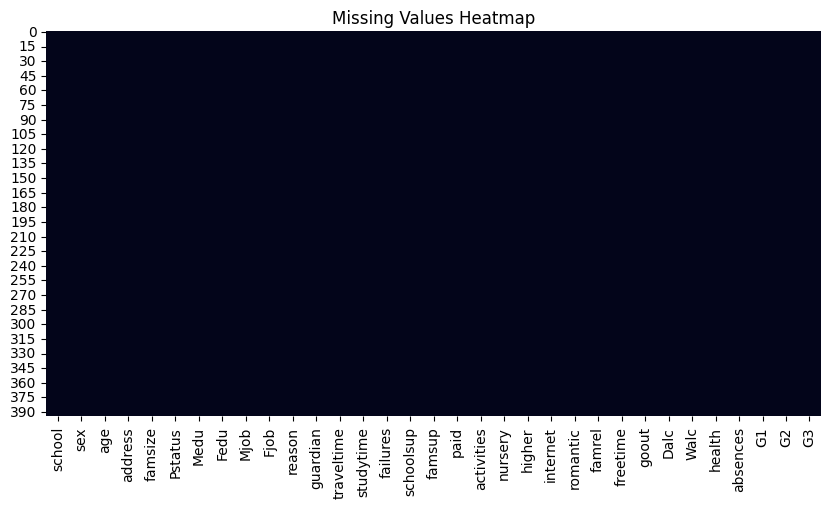

In [15]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

### Finding
No missing values were found in the dataset.

In [17]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [19]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [21]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


In [23]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 school
school
GP    349
MS     46
Name: count, dtype: int64

 sex
sex
F    208
M    187
Name: count, dtype: int64

 address
address
U    307
R     88
Name: count, dtype: int64

 famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64

 Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64

 Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

 Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

 reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

 guardian
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

 schoolsup
schoolsup
no     344
yes     51
Name: count, dtype: int64

 famsup
famsup
yes    242
no     153
Name: count, dtype: int64

 paid
paid
no     214
yes    181
Name: count, dtype: int64

 activities
activities
yes    201
no     194
Name: count, dty

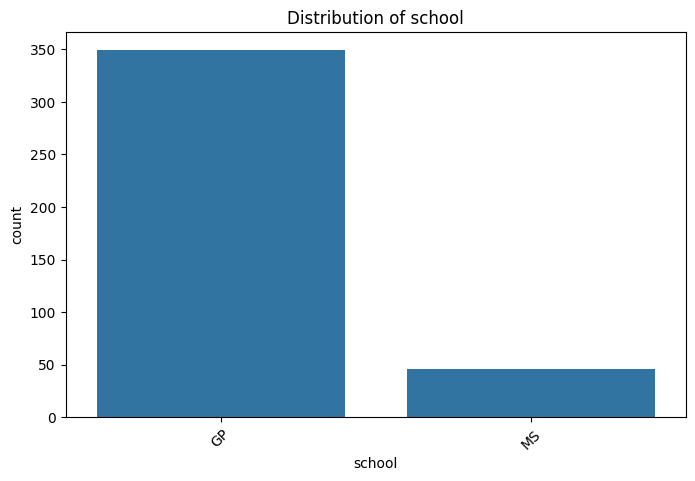

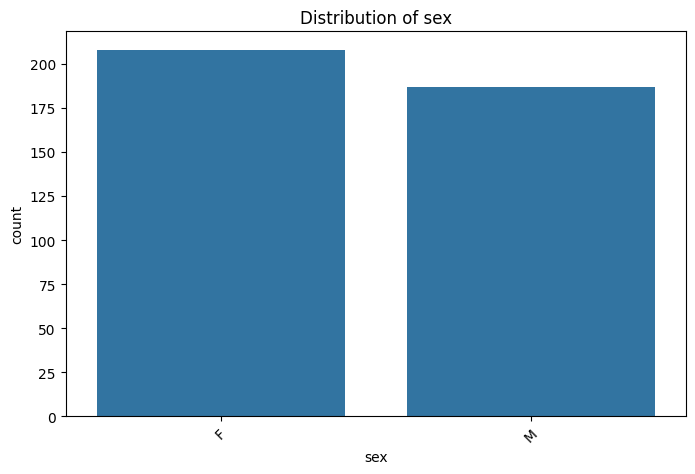

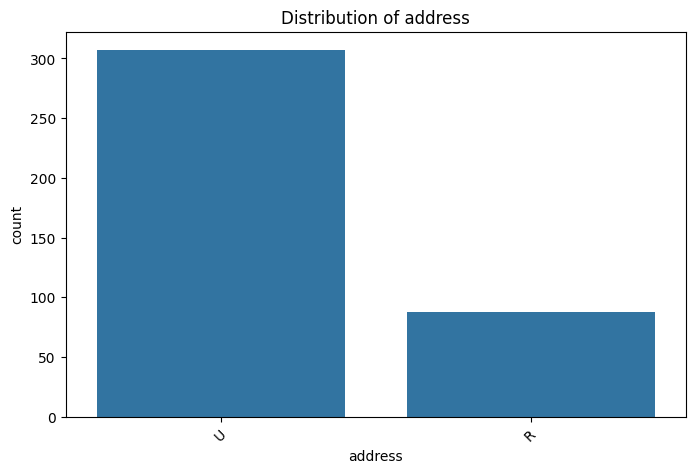

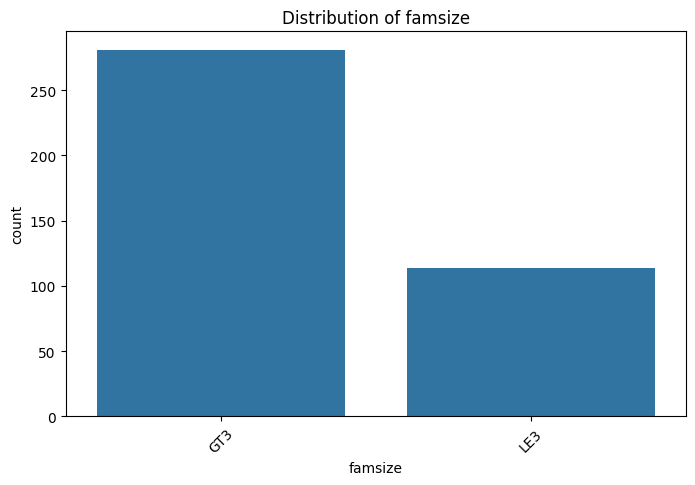

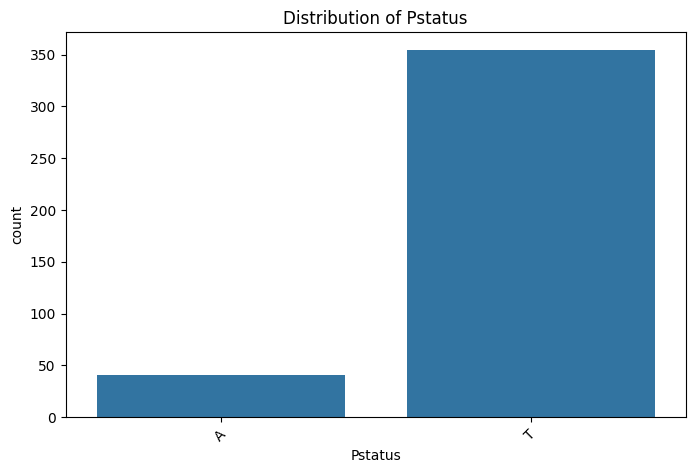

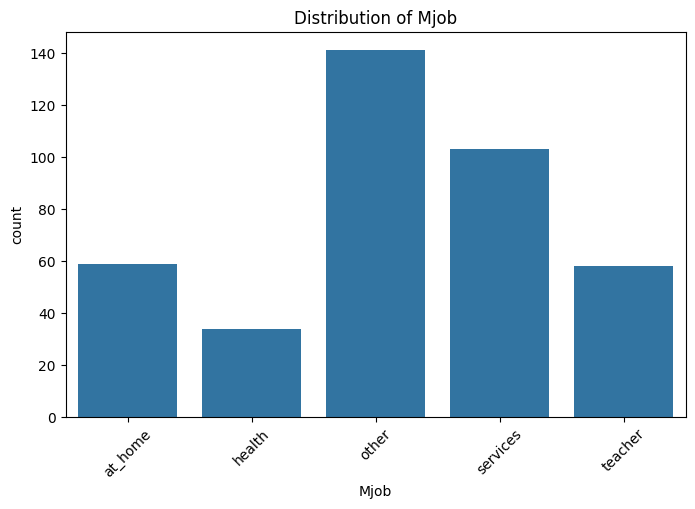

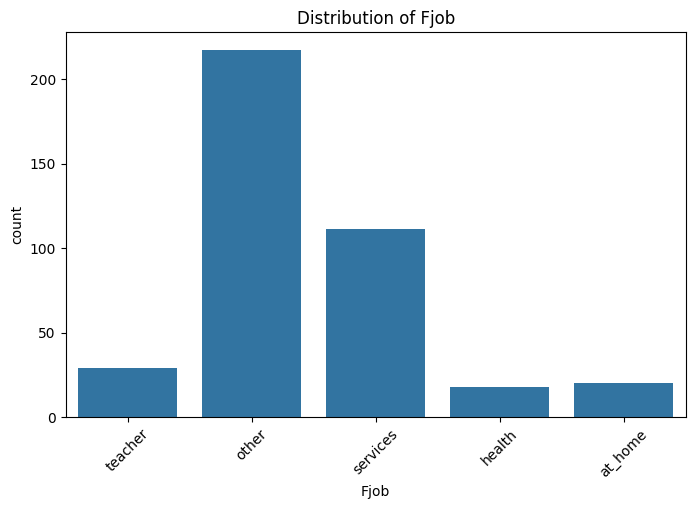

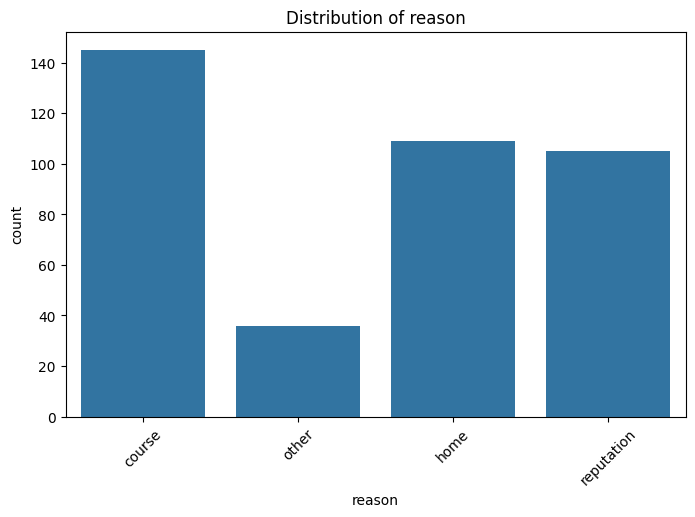

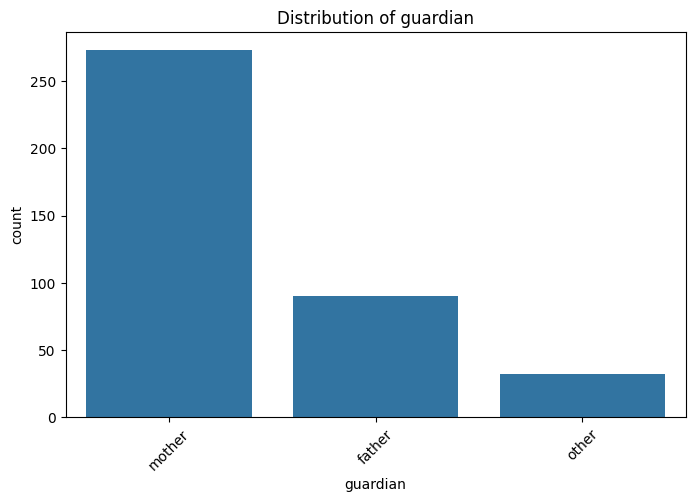

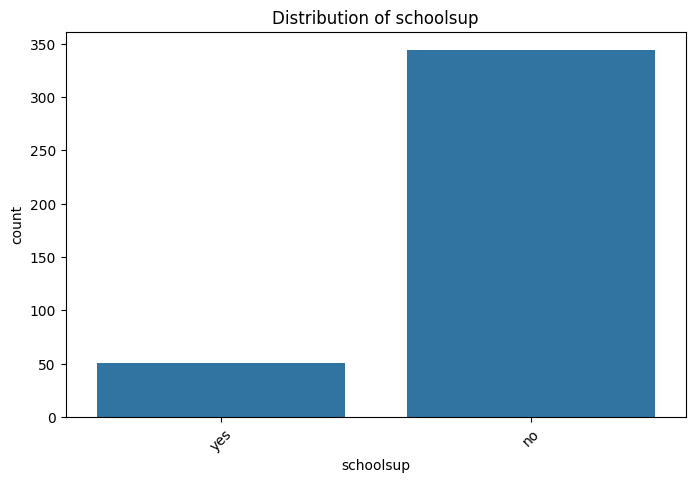

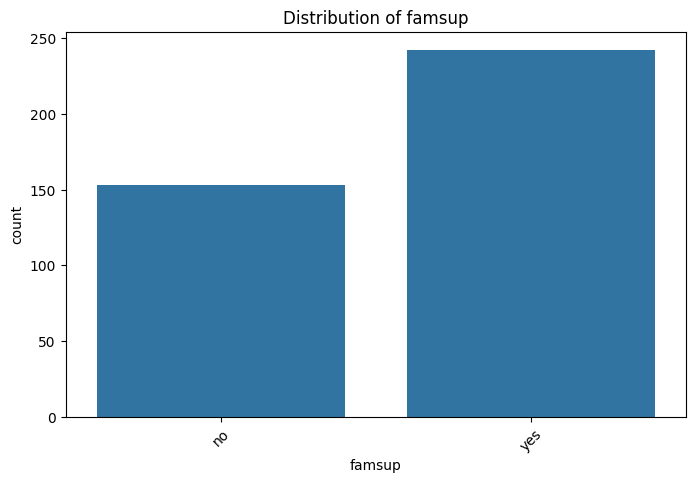

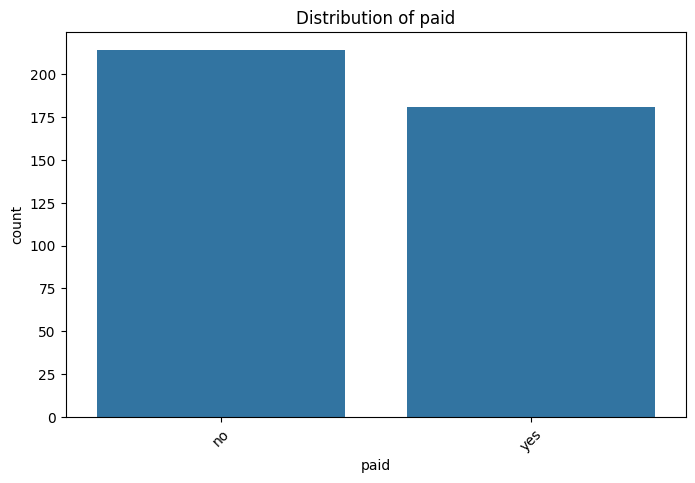

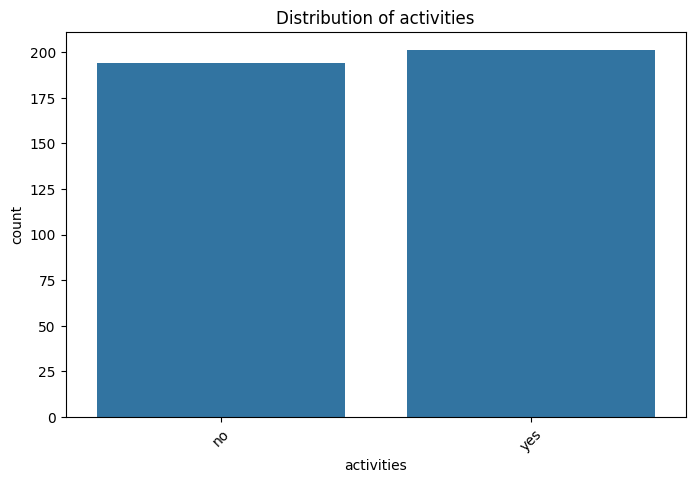

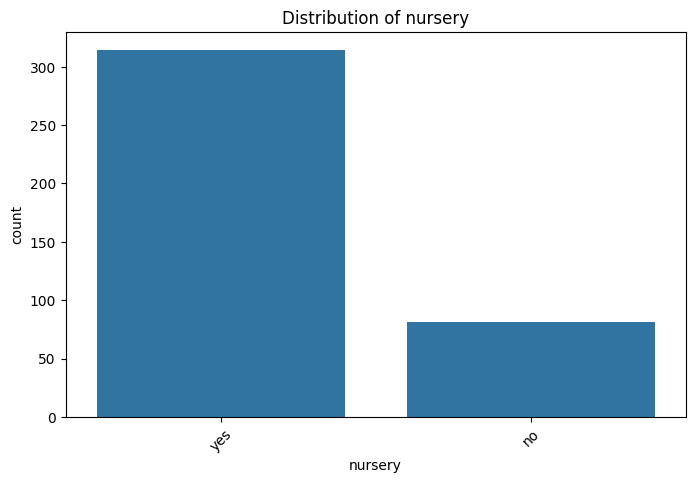

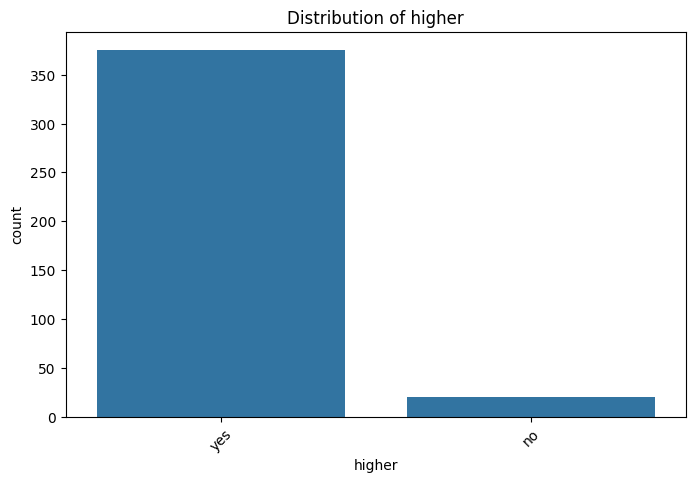

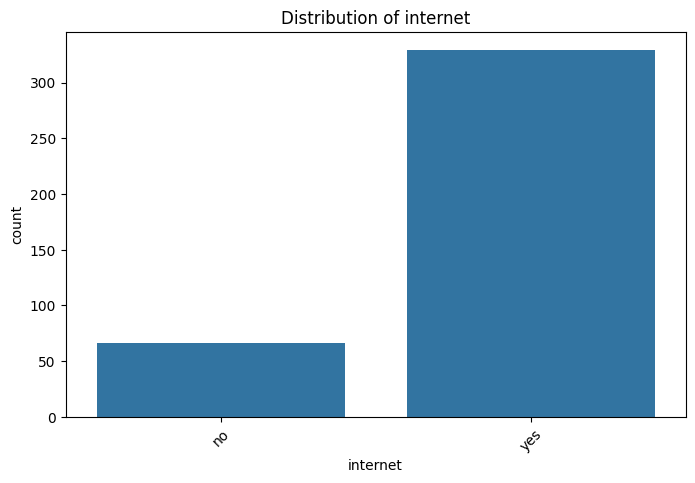

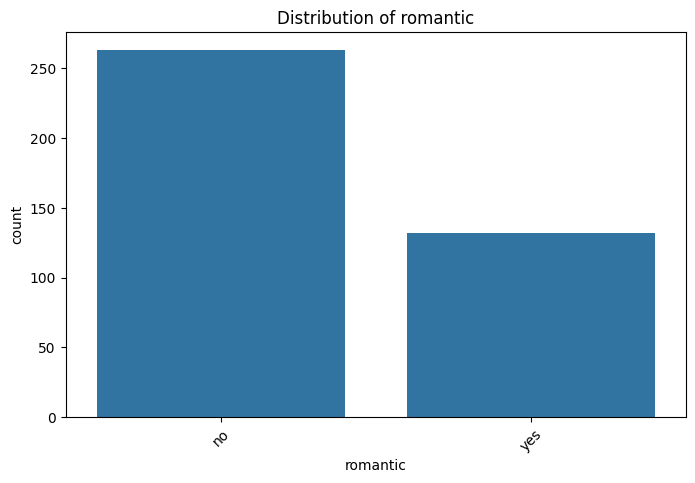

In [25]:
for column in categorical_columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45)
    plt.show()

In [27]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')


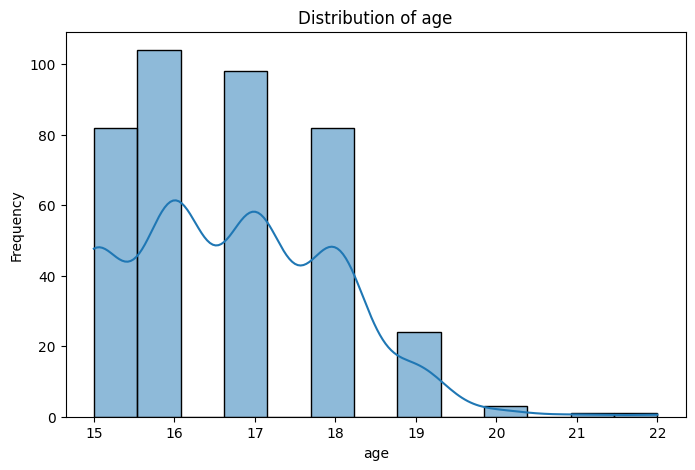

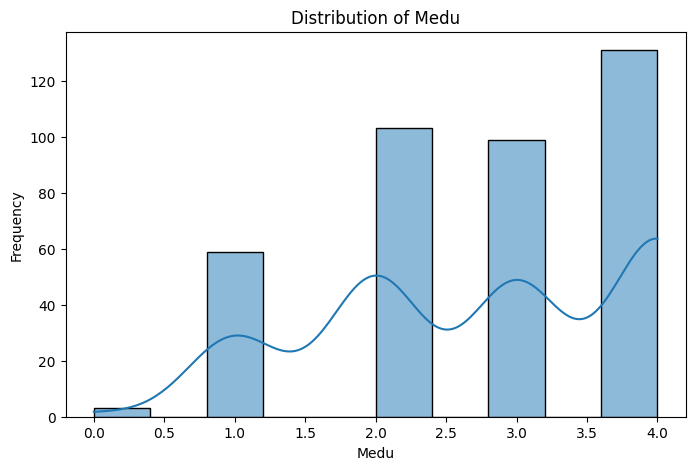

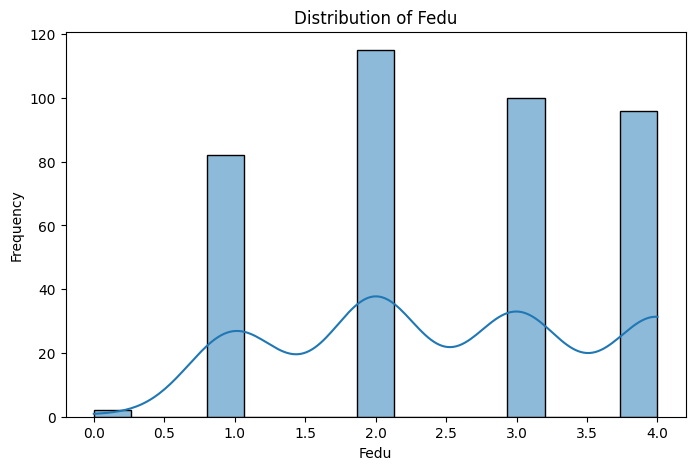

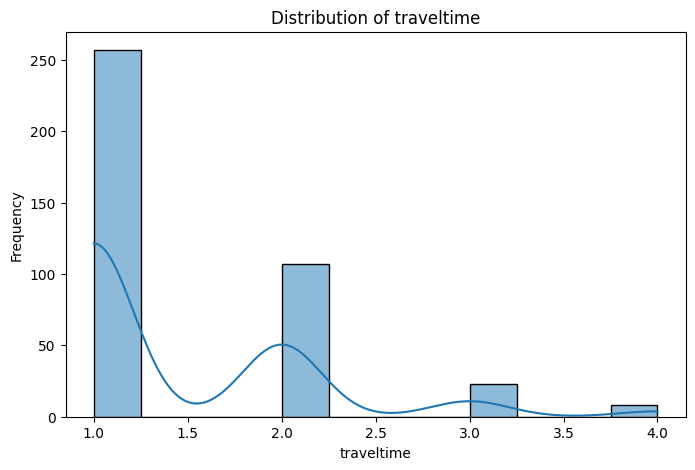

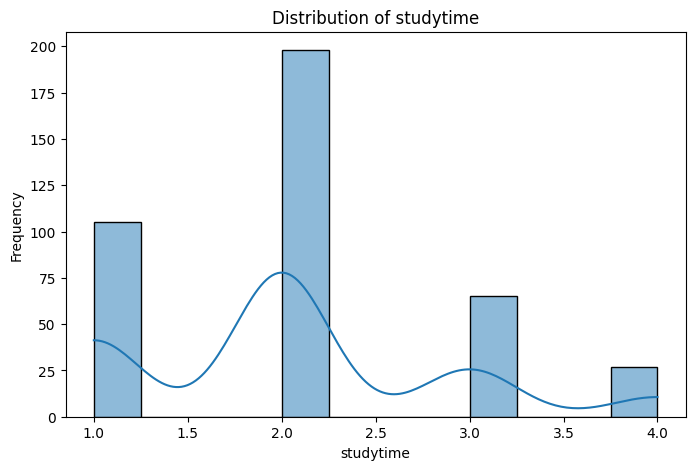

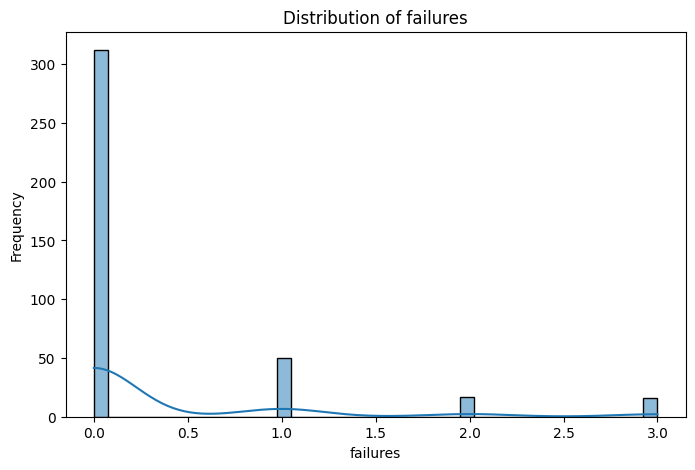

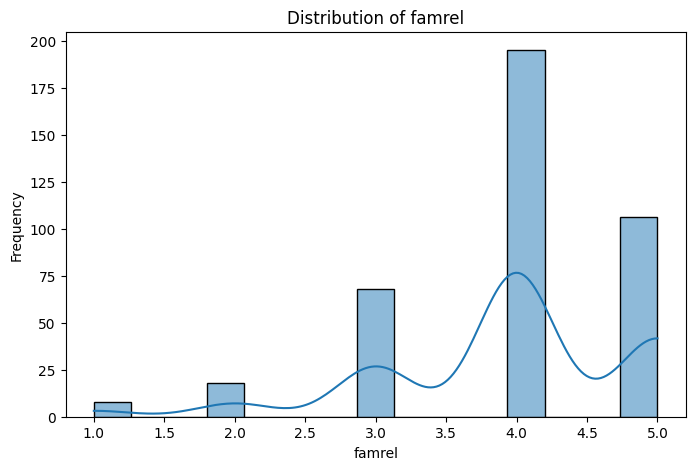

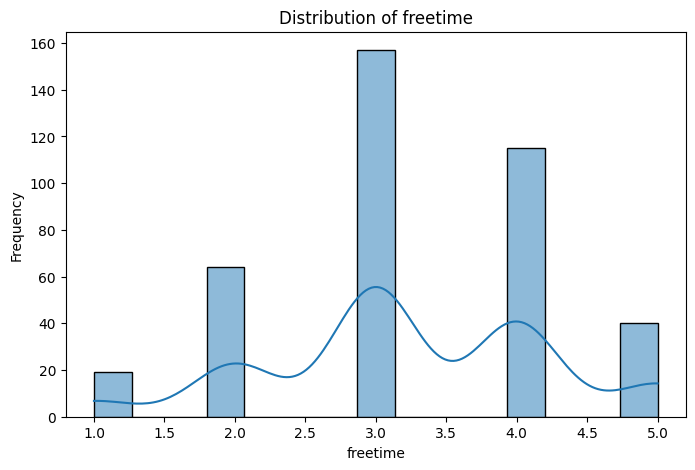

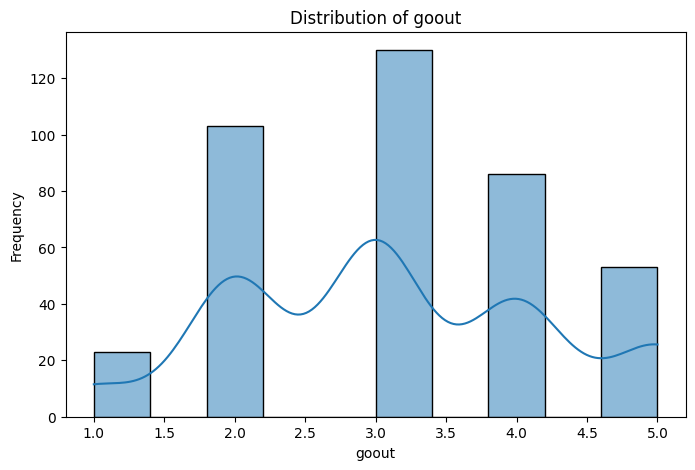

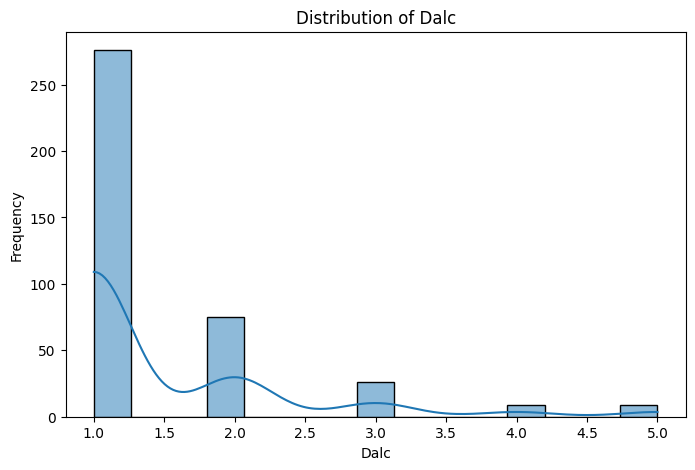

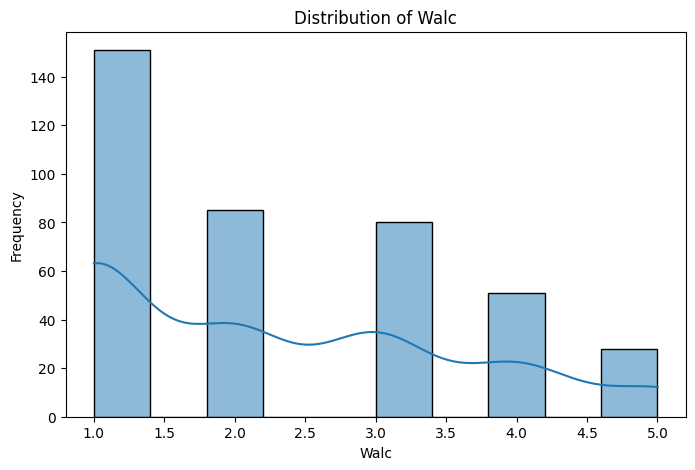

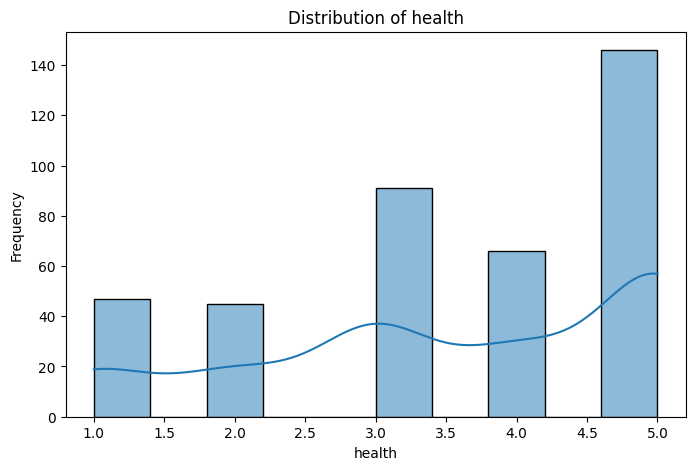

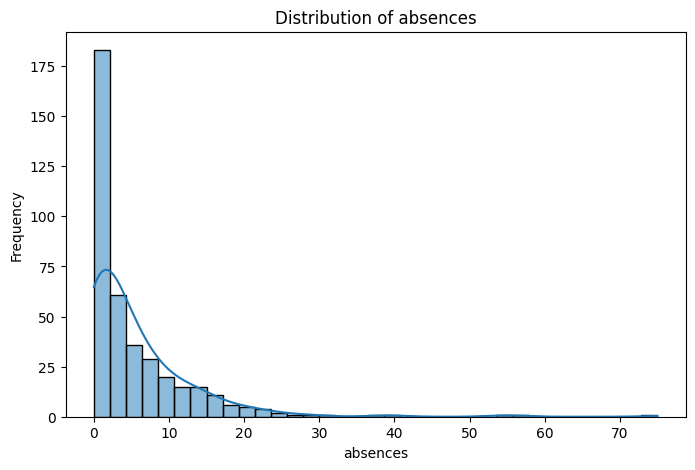

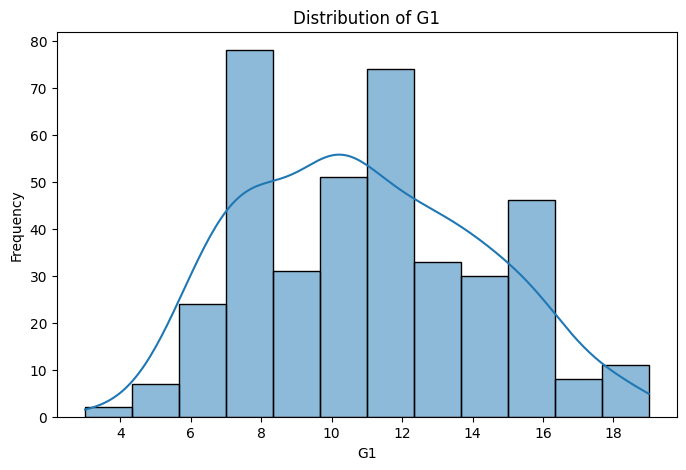

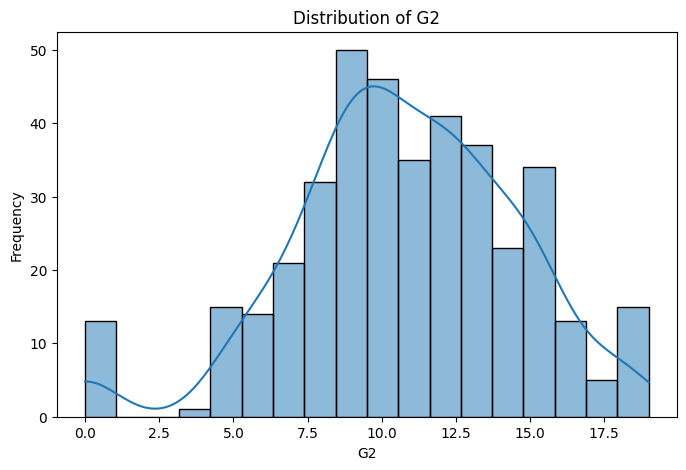

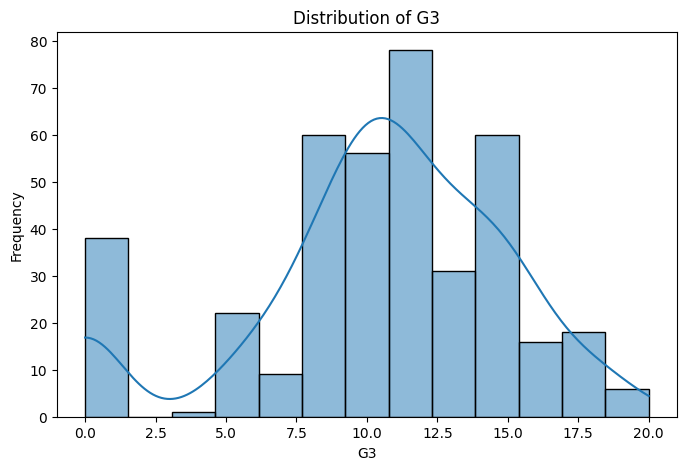

In [29]:
for column in numerical_columns:
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[column], kde=True)
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

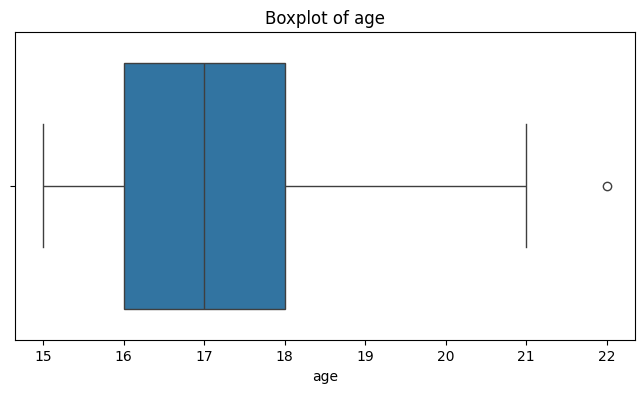

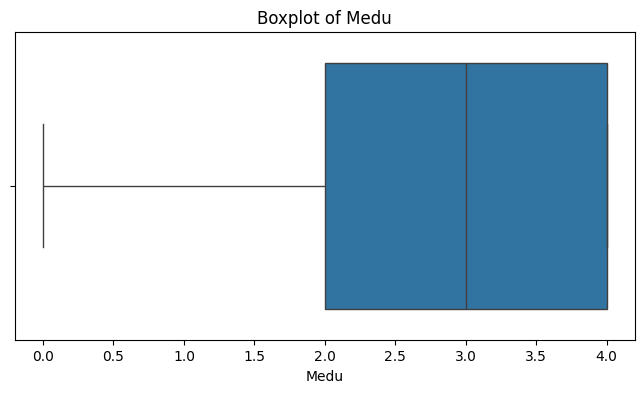

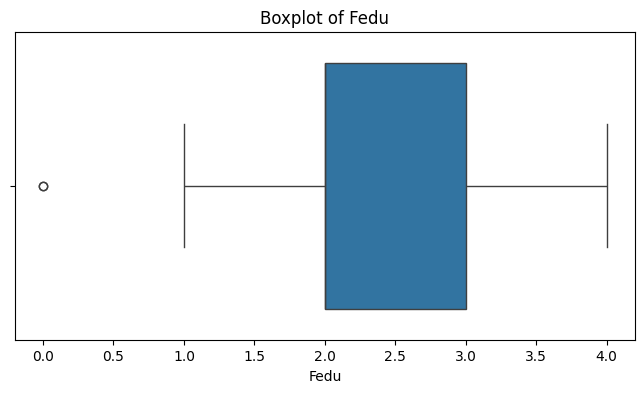

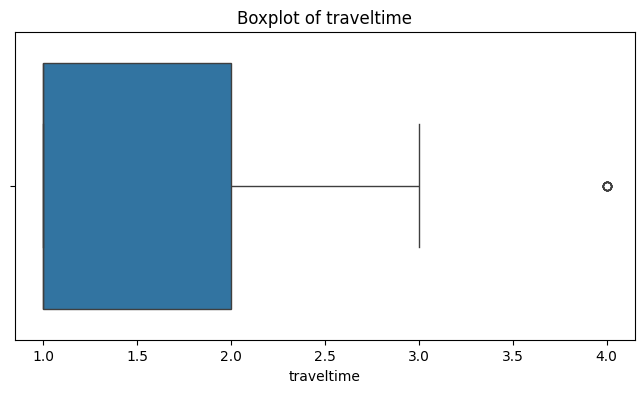

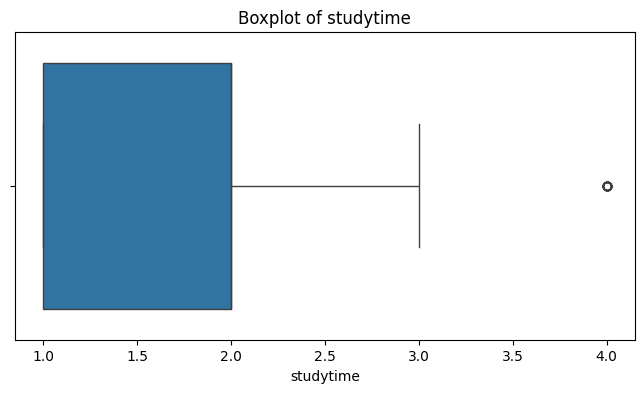

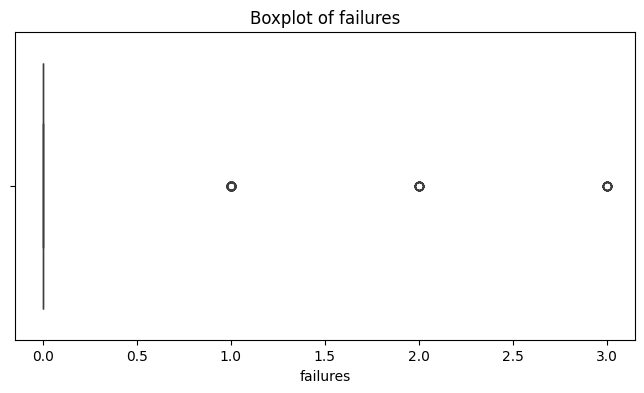

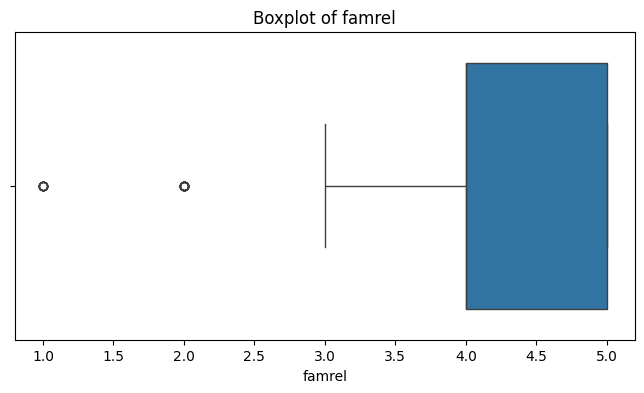

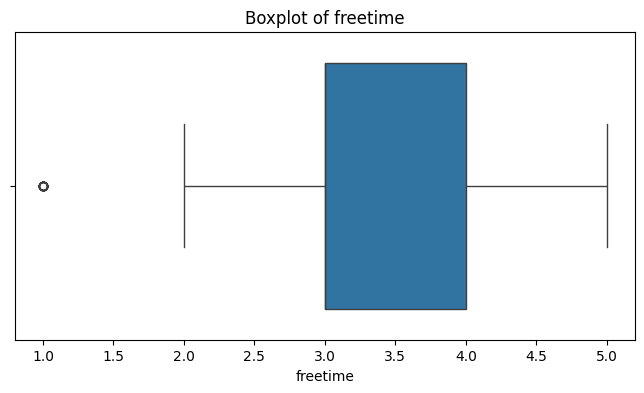

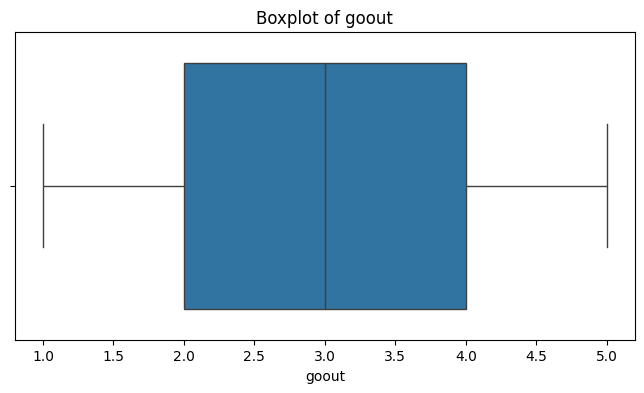

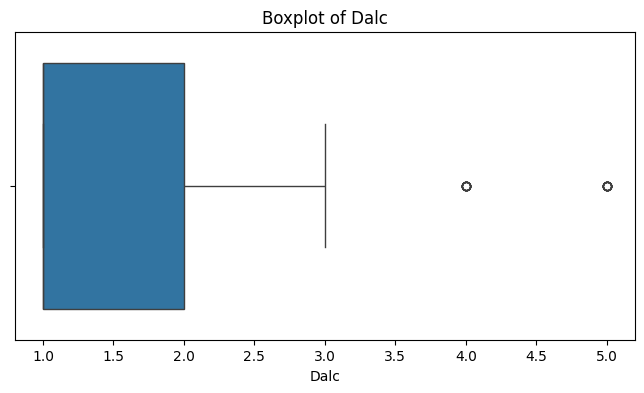

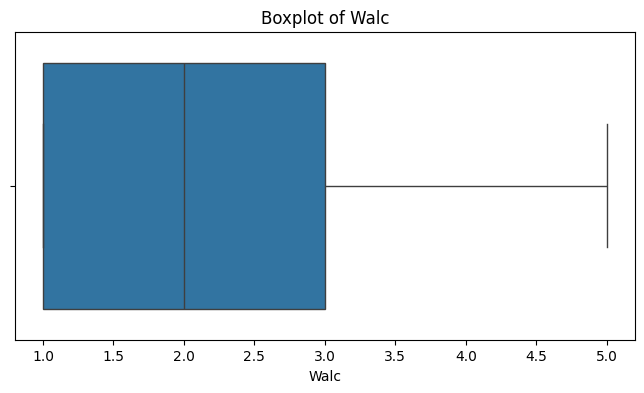

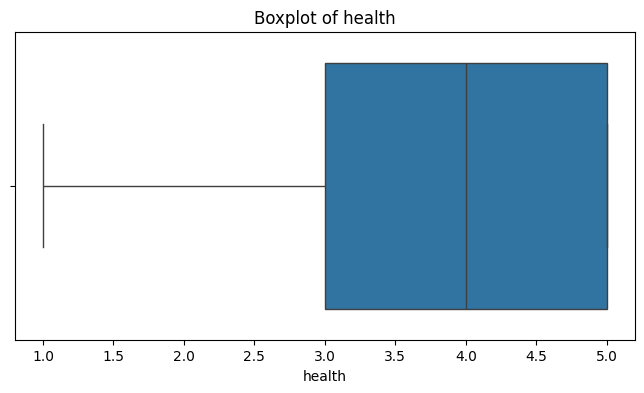

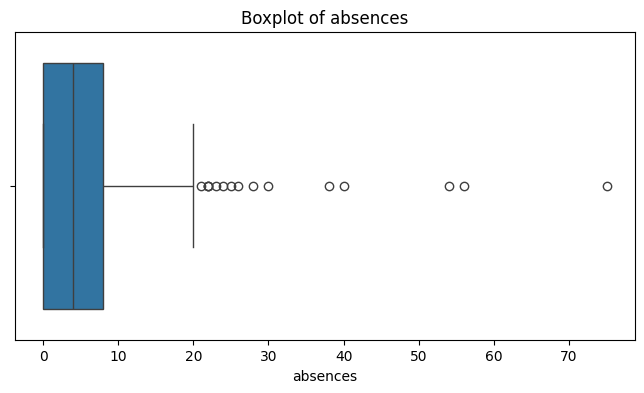

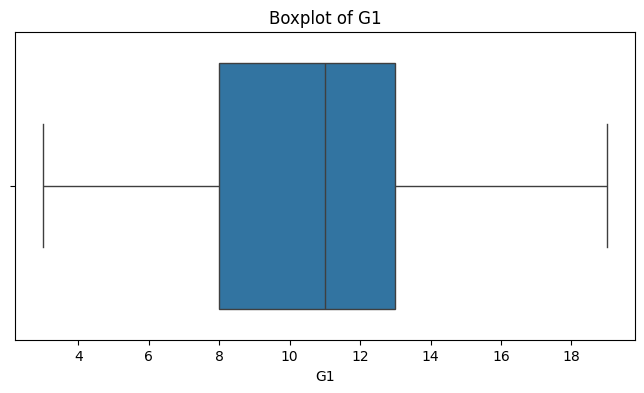

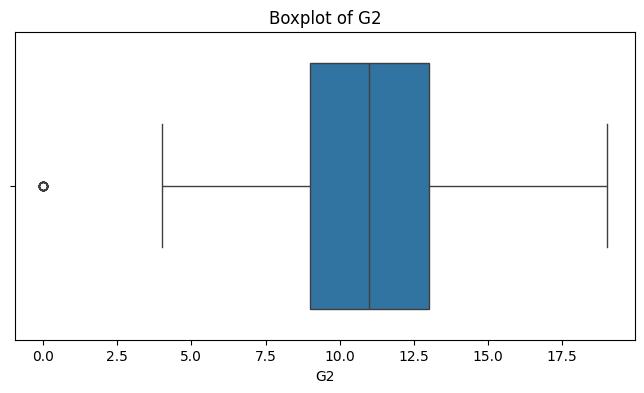

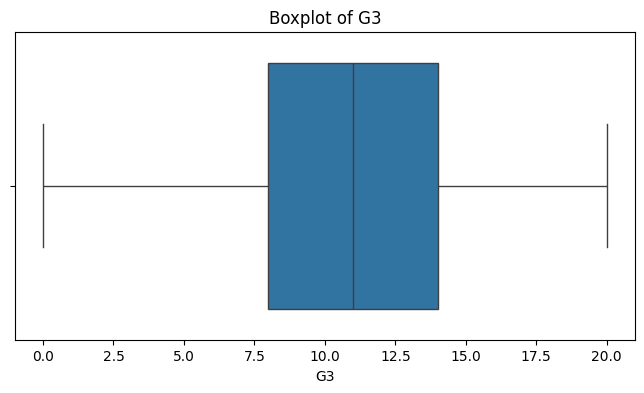

In [31]:
for column in numerical_columns:
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Boxplot of {column}")
    plt.show()

In [33]:
for column in numerical_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(column, ":", len(outliers), "potential outliers")

age : 1 potential outliers
Medu : 0 potential outliers
Fedu : 2 potential outliers
traveltime : 8 potential outliers
studytime : 27 potential outliers
failures : 83 potential outliers
famrel : 26 potential outliers
freetime : 19 potential outliers
goout : 0 potential outliers
Dalc : 18 potential outliers
Walc : 0 potential outliers
health : 0 potential outliers
absences : 15 potential outliers
G1 : 0 potential outliers
G2 : 13 potential outliers
G3 : 0 potential outliers


In [35]:
correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix)

                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.163658 -0.163438    0.070641  -0.004140  0.243665   
Medu       -0.163658  1.000000  0.623455   -0.171639   0.064944 -0.236680   
Fedu       -0.163438  0.623455  1.000000   -0.158194  -0.009175 -0.250408   
traveltime  0.070641 -0.171639 -0.158194    1.000000  -0.100909  0.092239   
studytime  -0.004140  0.064944 -0.009175   -0.100909   1.000000 -0.173563   
failures    0.243665 -0.236680 -0.250408    0.092239  -0.173563  1.000000   
famrel      0.053940 -0.003914 -0.001370   -0.016808   0.039731 -0.044337   
freetime    0.016434  0.030891 -0.012846   -0.017025  -0.143198  0.091987   
goout       0.126964  0.064094  0.043105    0.028540  -0.063904  0.124561   
Dalc        0.131125  0.019834  0.002386    0.138325  -0.196019  0.136047   
Walc        0.117276 -0.047123 -0.012631    0.134116  -0.253785  0.141962   
health     -0.062187 -0.046878  0.014742    0.007501  -0.075616  0.065827   

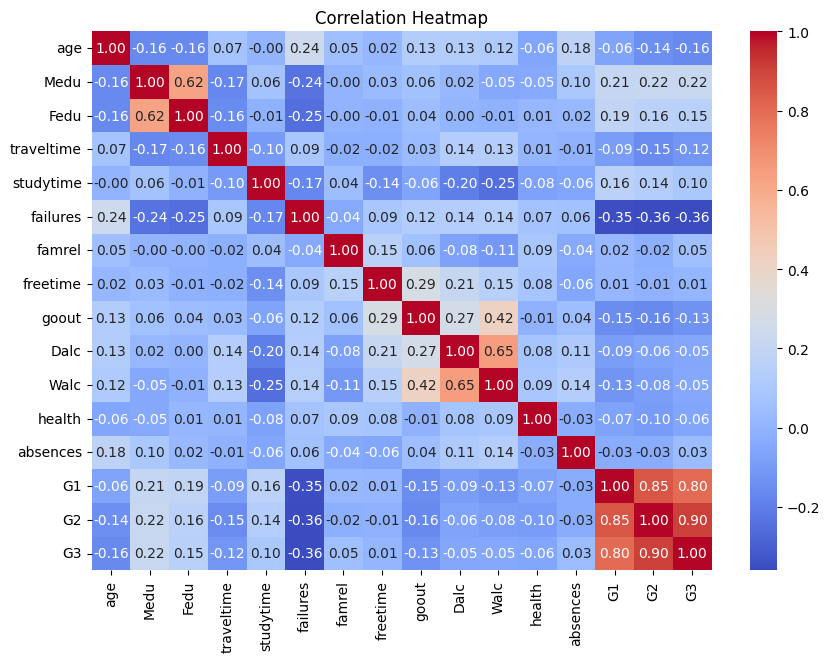

In [37]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

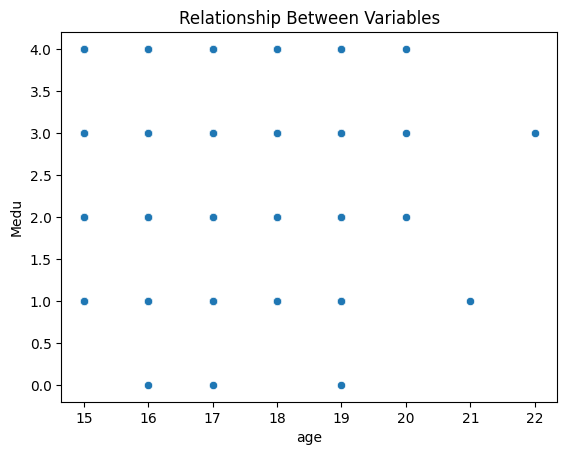

In [39]:
sns.scatterplot(
    data=df,
    x=numerical_columns[0],
    y=numerical_columns[1]
)

plt.title("Relationship Between Variables")
plt.show()

In [41]:
categorical_column = categorical_columns[0]
numerical_column = numerical_columns[0]

grouped_data = df.groupby(categorical_column)[numerical_column].mean()

print(grouped_data)

school
GP    16.521490
MS    18.021739
Name: age, dtype: float64


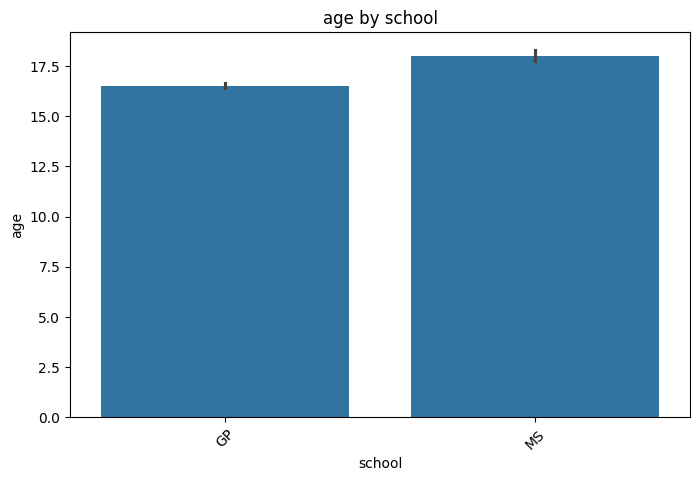

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x=categorical_column,
    y=numerical_column
)

plt.xticks(rotation=45)
plt.title(f"{numerical_column} by {categorical_column}")
plt.show()

In [44]:
groups = df[categorical_column].dropna().unique()

print(groups)

['GP' 'MS']


In [48]:
group1 = df[df[categorical_column] == groups[0]][numerical_column].dropna()

group2 = df[df[categorical_column] == groups[1]][numerical_column].dropna()

t_stat, p_value = stats.ttest_ind(group1, group2)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -8.084346495083679
P-value: 7.810628161628065e-15


### Hypothesis Testing Result

The p-value was compared with the significance level of 0.05.
The result indicates whether there is sufficient statistical evidence
to reject the null hypothesis.

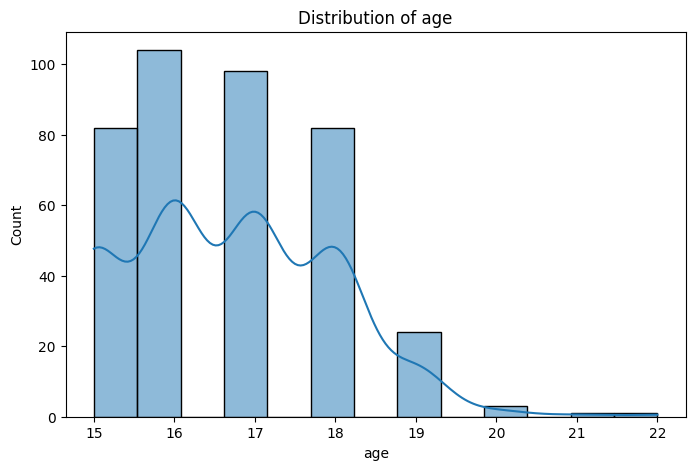

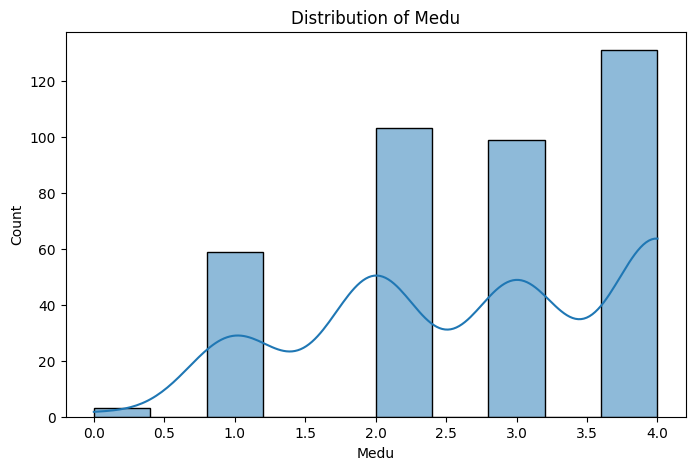

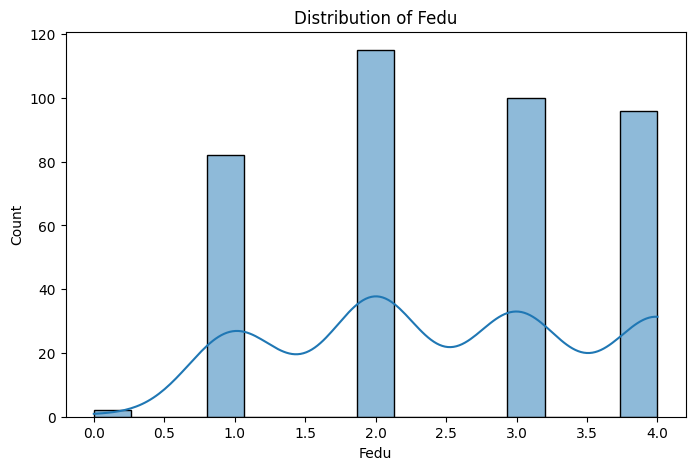

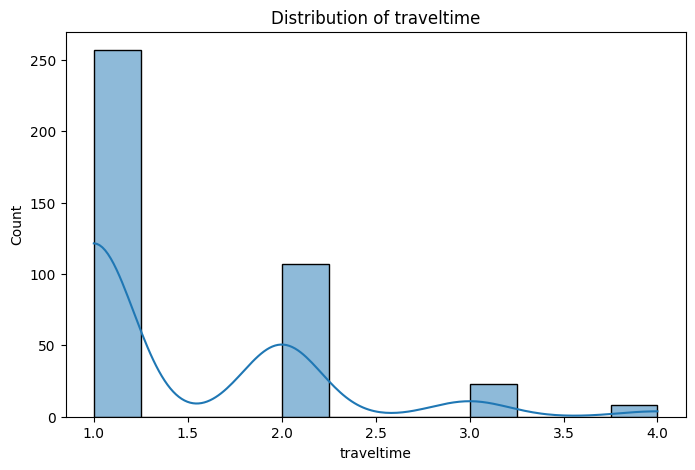

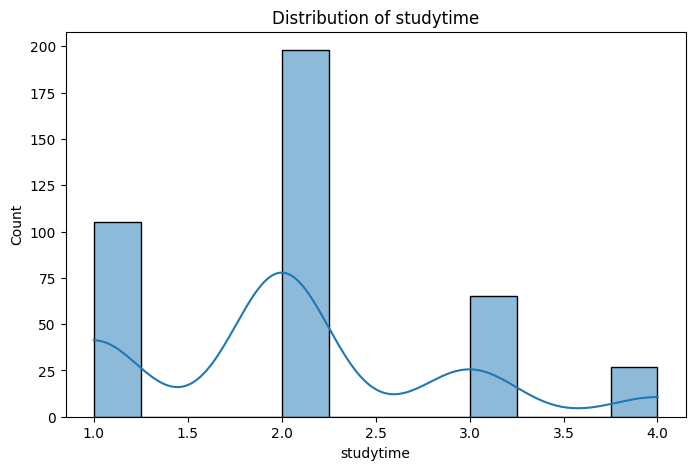

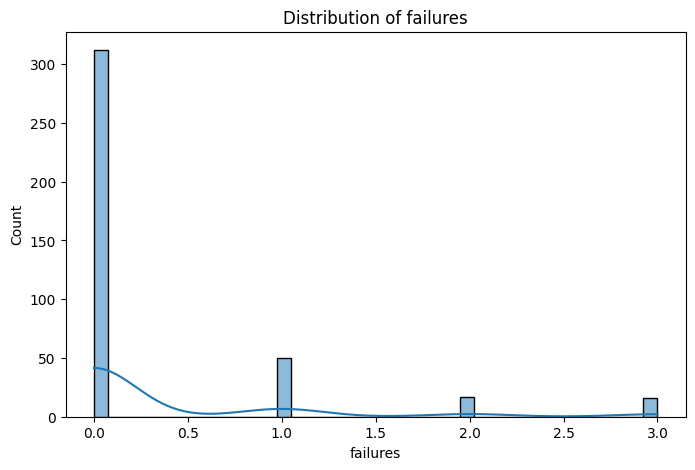

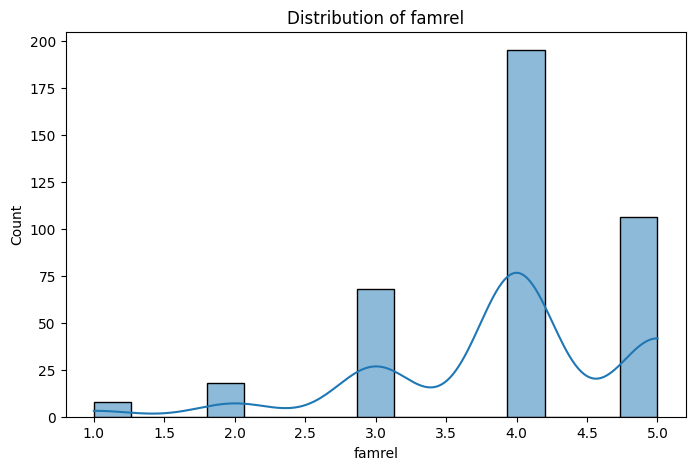

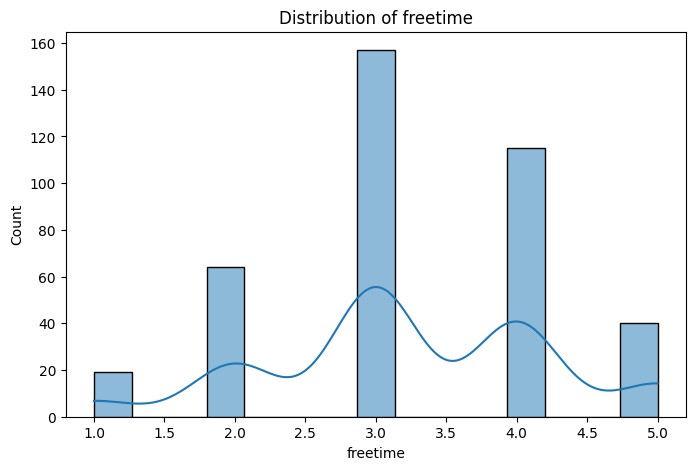

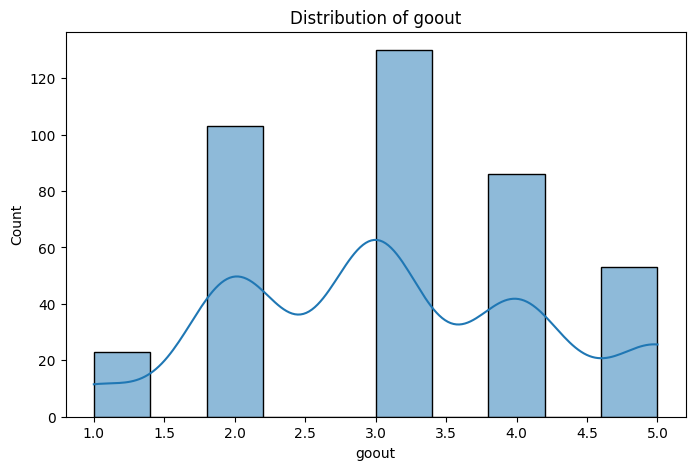

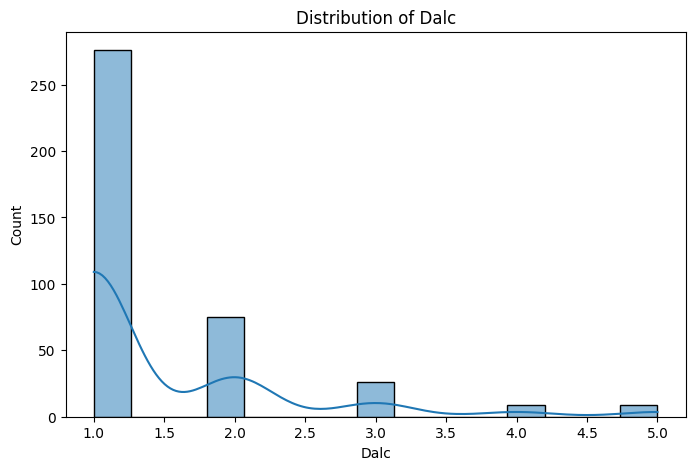

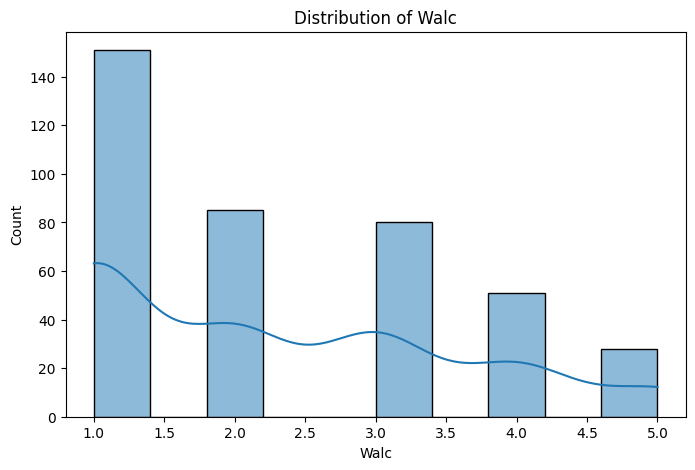

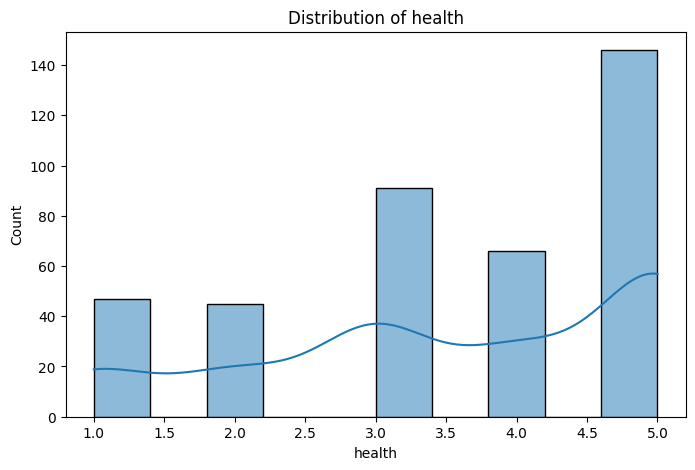

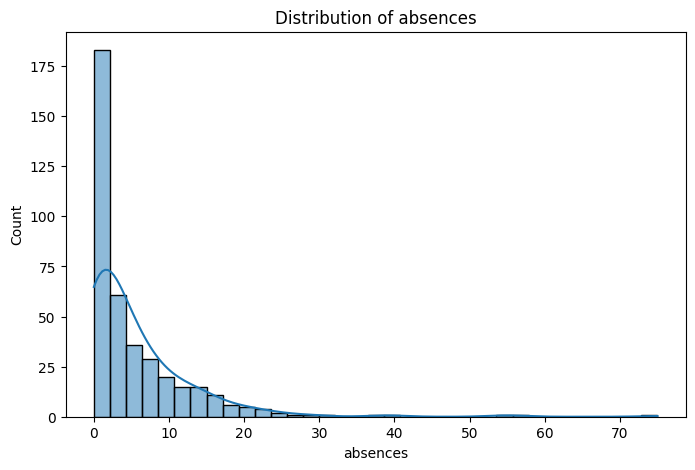

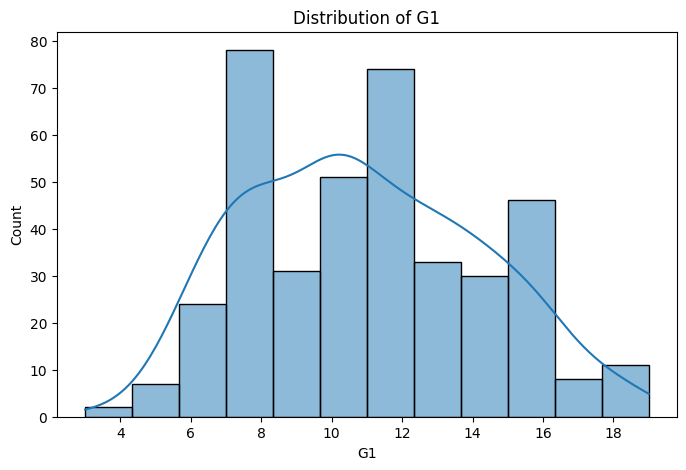

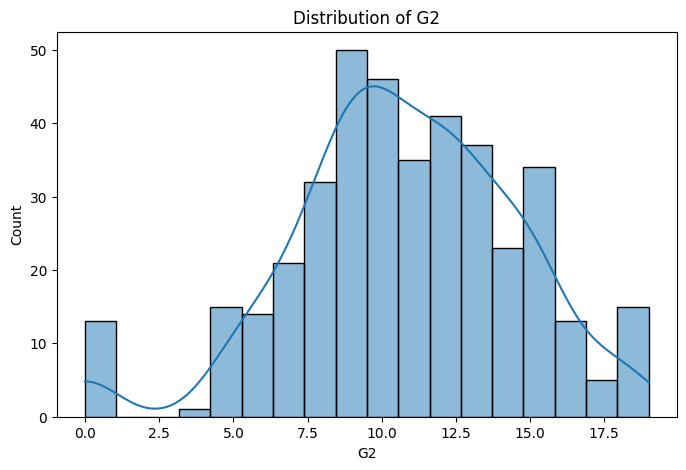

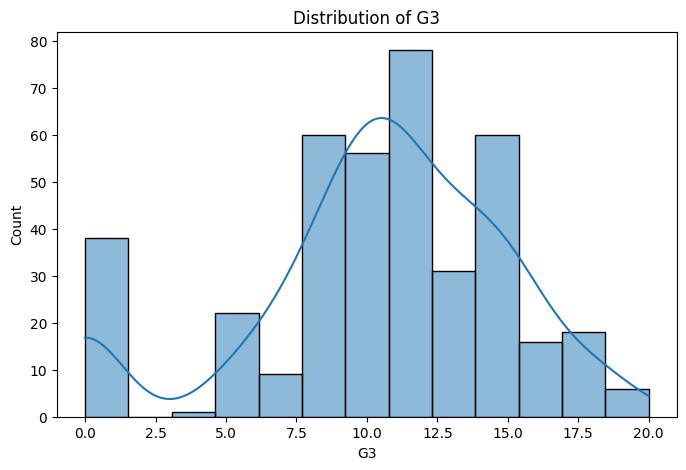

In [50]:
for column in numerical_columns:
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[column].dropna(), kde=True)
    
    plt.title(f"Distribution of {column}")
    plt.show()

In [52]:
sample = df[numerical_columns[0]].dropna()

if len(sample) > 5000:
    sample = sample.sample(5000, random_state=42)

stat, p = stats.shapiro(sample)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 0.9105932030011303
P-value: 1.5887610313103728e-14


## Data Quality Issues

The following data quality aspects were checked:

- Missing values
- Duplicate records
- Incorrect data types
- Outliers
- Inconsistent categorical values
- Unusual numerical values
- Highly correlated variables
- Potentially imbalanced categories

In [54]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 school
['GP' 'MS']

 sex
['F' 'M']

 address
['U' 'R']

 famsize
['GT3' 'LE3']

 Pstatus
['A' 'T']

 Mjob
['at_home' 'health' 'other' 'services' 'teacher']

 Fjob
['teacher' 'other' 'services' 'health' 'at_home']

 reason
['course' 'other' 'home' 'reputation']

 guardian
['mother' 'father' 'other']

 schoolsup
['yes' 'no']

 famsup
['no' 'yes']

 paid
['no' 'yes']

 activities
['no' 'yes']

 nursery
['yes' 'no']

 higher
['yes' 'no']

 internet
['no' 'yes']

 romantic
['no' 'yes']
